# Access to Exercise Opportunities and Health Outcomes

## <span style="color:#ff69b4;">Rachel Nefesh</span>

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import geopandas
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

<div style="color: steelblue; font-size: 14px;">
<b>Data source: County Health Rankings & Roadmaps 2025<br>
(<a href="https://www.countyhealthrankings.org/" style="color: steelblue;">https://www.countyhealthrankings.org/</a>)<br>
This dataset contains county level health and socioeconomic indicators for all U.S. counties.</b>
</div>

In [74]:
df = pd.read_csv("analytic_data2025_v3.csv", low_memory=False)
print(f"Raw dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Raw dataset: 3204 rows, 796 columns


<div style="color: steelblue; font-size: 14px;">
<b>The raw dataset has 796 columns so I selected the variables I wanted to use for our analysis and renamed them.</b>
</div>

In [77]:
df_clean = df[[
    '5-digit FIPS Code',
    'State Abbreviation',
    'Name',
    'Adult Obesity raw value',
    'Physical Inactivity raw value',
    'Access to Exercise Opportunities raw value',
    'Food Environment Index raw value',
    'Median Household Income raw value',
    'Uninsured raw value',
    'Children in Poverty raw value',
    '% Rural raw value'
]].copy()

df_clean.columns = ['FIPS', 'state', 'county', 'obesity', 'inactivity',
                    'exercise_access', 'food_env', 'income', 'uninsured',
                    'poverty', 'rural']

df_clean = df_clean.iloc[1:]

for col in ['obesity', 'inactivity', 'exercise_access', 'food_env',
            'income', 'uninsured', 'poverty', 'rural']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna()

print(f"Clean dataset: {df_clean.shape[0]} counties across {df_clean['state'].nunique()} states including DC")
df_clean.describe().round(3)

Clean dataset: 3104 counties across 51 states including DC


,FIPS,obesity,inactivity,exercise_access,food_env,income,uninsured,poverty,rural
count,3104.000,3104.000,3104.000,3104.000,3104.000,3104.000,3104.000,3104.000,3104.000
mean,30415.889,0.378,0.263,0.623,7.477,65824.228,0.104,0.189,0.628
std,15122.940,0.047,0.052,0.228,1.183,16444.903,0.046,0.080,0.336
min,1000.000,0.177,0.118,0.000,0.000,28579.000,0.021,0.031,0.000
25%,19010.500,0.352,0.227,0.479,6.875,54911.250,0.069,0.130,0.343
50%,29182.000,0.384,0.259,0.646,7.600,63160.500,0.094,0.177,0.641
75%,45061.500,0.409,0.297,0.795,8.300,73332.250,0.131,0.232,1.000
max,56045.000,0.530,0.473,1.000,10.000,173655.000,0.377,0.632,1.000


## <span style="color:#ff69b4;">Plot #1: Physical Inactivity vs Obesity</span>

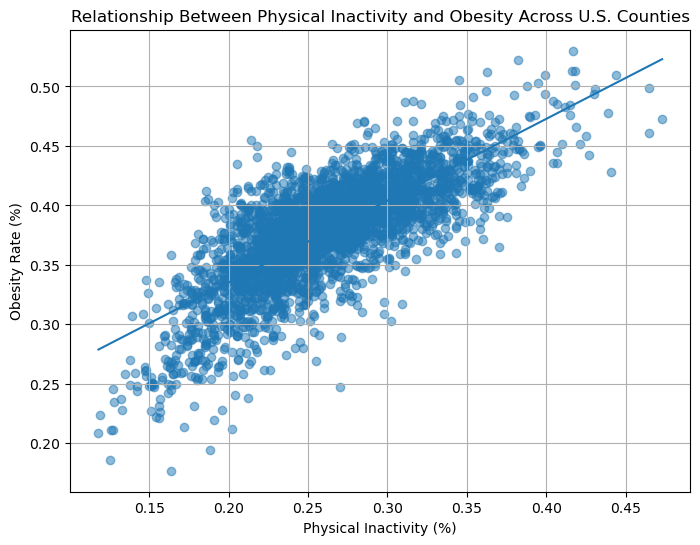

In [80]:
fig, ax = plt.subplots(figsize=(8,6))

x = df_clean['inactivity']
y = df_clean['obesity']

ax.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b)

ax.set_xlabel('Physical Inactivity (%)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Relationship Between Physical Inactivity and Obesity Across U.S. Counties')

ax.grid(True)

plt.savefig("proof_of_concept.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="color: steelblue; font-size: 14px;">
<b>This scatter plot shows the relationship between physical inactivity rates and adult obesity rates across 3,104 U.S. counties. We can see that there is a positive relationship: as physical inactivity increases, obesity rates tend to rise as well. This confirms that the data is acting as expected.</b>
</div>


## <span style="color:#ff69b4;">Plot #2: Exercise Access vs Obesity</span>

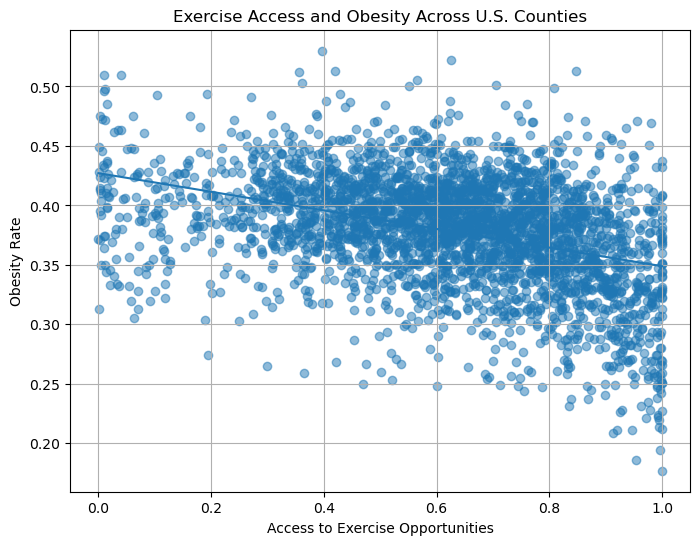

In [84]:
fig, ax = plt.subplots(figsize=(8,6))

x = df_clean['exercise_access']
y = df_clean['obesity']

ax.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)

x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b)

ax.set_xlabel('Access to Exercise Opportunities')
ax.set_ylabel('Obesity Rate')
ax.set_title('Exercise Access and Obesity Across U.S. Counties')

ax.grid(True)

plt.show()

<div style="color: steelblue; font-size: 14px;">
<b>This scatter plot shows the relationship between access to exercise opportunities and adult obesity rates across 3,104 U.S. counties. We can see that there is a negative relationship: as exercise access increases, obesity rates tend to decrease, as shown by the downward sloping trend line. However the scatter is much wider than Plot 1 so exercise access alone does not strongly predict obesity which introduces the potential of omitted variable bias. This is a motivating factor for our regression model below where we add controls to better model the independent effect of exercise access on obesity.</b>
</div>

## <span style="color:#ff69b4;">Plot #3: Exercise Access vs Physical Inactivity</span>

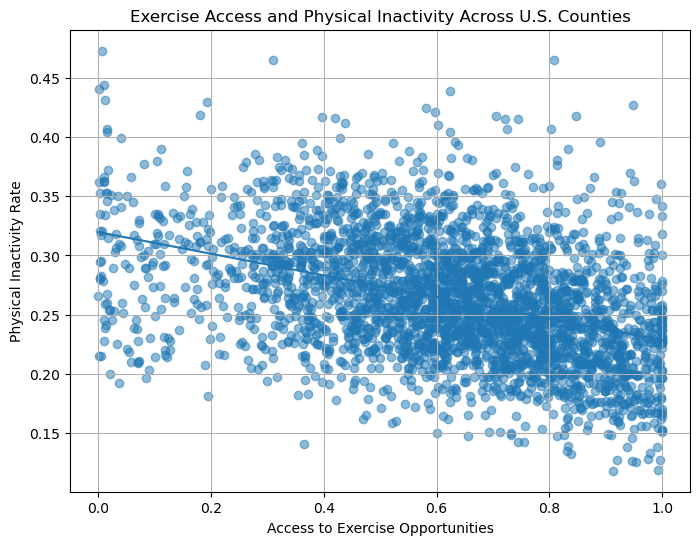

In [88]:
fig, ax = plt.subplots(figsize=(8,6))

x = df_clean['exercise_access']
y = df_clean['inactivity']

ax.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b)

ax.set_xlabel('Access to Exercise Opportunities')
ax.set_ylabel('Physical Inactivity Rate')
ax.set_title('Exercise Access and Physical Inactivity Across U.S. Counties')
ax.grid(True)

plt.show()

<div style="color: steelblue; font-size: 14px;">
<b>This scatter plot shows the relationship between access to exercise opportunities and physical inactivity rates across U.S. counties. We can see that there is a negative relationship: counties with better exercise access tend to have lower physical inactivity rates. However the scatter is also pretty wide, and the trend line is relatively flat which suggests that exercise access doesn't have a major effect on physical inactivity. This makes intuitive sense because just having access to exercise facilities does not necessarily guarantee that residents will use them.</b>
</div>

<div style="color: steelblue; font-size: 14px;">
<b>Here we are creating a basic OLS model where we are regressing adult obesity rates on exercise access with no controls</b>
</div>

In [92]:
import statsmodels.formula.api as smf

res1 = smf.ols('obesity ~ exercise_access', data=df_clean).fit(cov_type='HC3')
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:                obesity   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     420.5
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           9.81e-88
Time:                        11:45:49   Log-Likelihood:                 5366.2
No. Observations:                3104   AIC:                        -1.073e+04
Df Residuals:                    3102   BIC:                        -1.072e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.4271      0.002    1

<div style="color: steelblue; font-size: 14px;">
<b>Based on the regression output, we can see that counties with higher exercise access have lower obesity rates. A 1 unit increase in exercise access is associated with a 7.9 percentage point decrease in obesity rate. This relationship is statistically significant at the 1% level (p value is essentially zero). The R^2 value is 15% which means that exercise only explains about 15% of the variation in obesity rates across counties which means that the majority of variation in obesity is driven by other factors not captured in this baseline model</b>
</div>

In [95]:
# Model 2: adding income, the main confounder
res2 = smf.ols('obesity ~ exercise_access + np.log(income)', data=df_clean).fit(cov_type='HC3')
print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:                obesity   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     882.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          4.43e-304
Time:                        11:45:50   Log-Likelihood:                 5943.0
No. Observations:                3104   AIC:                        -1.188e+04
Df Residuals:                    3101   BIC:                        -1.186e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.6501      0.037     

<div style="color: steelblue; font-size: 14px;">
<b>Here we are adding median household income as a control variable. Income increased R^2 from about 15% to about 41%. This tells us that income was a huge confounder and that it captures a lot of the variation in county obesity rates. Also, the exercise_access coefficient decreased from -0.078 to -0.028 which means that it went from explaining a lot in the model to explaining much less. This coefficient instability is the main finding of the presence of omitted variable bias</b>
</div>

In [98]:
# Model 3:  add all controls (food access, healthcare, poverty, rural)
res3 = smf.ols('obesity ~ exercise_access + np.log(income) + food_env + uninsured + poverty + rural',
               data=df_clean).fit(cov_type='HC3')

print(res3.summary())

                            OLS Regression Results                            
Dep. Variable:                obesity   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     318.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          7.34e-319
Time:                        11:45:50   Log-Likelihood:                 5956.2
No. Observations:                3104   AIC:                        -1.190e+04
Df Residuals:                    3097   BIC:                        -1.186e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.5478      0.070     

<div style="color: steelblue; font-size: 14px;">
<b>Model 3 accounts for all the controls like food environment, uninsured rate, poverty, and rurality. These controls barely change R^2 (0.412 --> 0.417) which implies that once income is accounted for, these other factors dont explain much. The exercise_access coefficient does remain significant and negative, meaning the relationship between exercise access and obesity holds up even after controlling for a broad set of socioeconomic factors. There is a multicollinearity warning at the bottom which notes that income, poverty, and uninsured rates are all correlated with each other, but this does not affect our results since the main variable of interest (exercise access) is stable and significant across the three models</b>
</div>


 <div style="color: steelblue; font-size: 14px;">
<b>These results suggest that while exercise access matters, income and poverty are the dominant drivers of county level obesity disparities</b>
 </div>

<div style="color: steelblue; font-size: 14px;">
<b>Here we split counties into two groups based on whether their median household income is above or below the median across all counties. This lets us ask: "Is exercise access equally important for reducing obesity in wealthy and poor counties, or does the relationship look different depending on income level?"</b>
</div>

In [103]:
df_clean['high_income'] = (df_clean['income'] > df_clean['income'].median()).astype(int)

res_low  = smf.ols('obesity ~ exercise_access', 
                    data=df_clean[df_clean['high_income']==0]).fit(cov_type='HC3')
res_high = smf.ols('obesity ~ exercise_access', 
                    data=df_clean[df_clean['high_income']==1]).fit(cov_type='HC3')

print("Low income counties:", res_low.params['exercise_access'])
print("High income counties:", res_high.params['exercise_access'])

Low income counties: -0.03506647234449844
High income counties: -0.07913162102878822


<div style="color: steelblue; font-size: 14px;">
<b>Interestingly, we can see that the effect of exercise access on obesity is more than twice as strong in high income counties compared to low income counties. So exercise access matters in both groups (both coefficients are negative) but it matters much more in wealthy counties than in poor ones. This makes sense intuitively because in high income counties residents have money, time, and flexibility. When a gym or park is nearby they actually use it. In low income counties even when exercise facilities exist nearby, residents may face other barriers that prevent them from using them such as safety concerns, working mutiple jobs, or affordability issues.</b>
</div>

In [106]:
r1 = res1.params['exercise_access']
r2 = res2.params['exercise_access']
r3 = res3.params['exercise_access']

table = pd.DataFrame(
    [[r1, r2, r3],
     ['no', 'yes', 'yes'],
     ['no', 'no', 'yes'],
     ['no', 'no', 'yes']],
    index=['Exercise access coef', 'Income control', 'Food environment control', 'Poverty/rural controls'],
    columns=['Model 1', 'Model 2', 'Model 3']
)
display(table)

,Model 1,Model 2,Model 3
Exercise access coef,-0.078189,-0.028443,-0.035833
Income control,no,yes,yes
Food environment control,no,no,yes
Poverty/rural controls,no,no,yes


<div style="color: steelblue; font-size: 14px;">
<b>This coefficient stability table summarizes how the exercise access coefficient changes across the three models. If your coefficient changes a lot when you add controls, it's a warning sign that the original estimate wasn't truly causal. We found that there was a 64% drop in coefficient estimates (-0.078 in Model 1 to -0.028 in Model 2) when income was added which confirms that there was omitted variable bias in the baseline model. Thus, confirming that income was masking the true independent effect of exercise access on obesity in the baseline model. The coefficient remains stable between Model 2 and Model 3 (-0.028 to -0.036) which confirms that once we controlled for income, adding food environment, poverty, and rurality did not significantly change the exercise access estimate.</b>
</div>

## <span style="color:#ff69b4;">CHOROPLETH MAP — ADULT OBESITY RATES BY U.S. COUNTY</span>

<div style="color: steelblue; font-size: 14px;">
<b>Here we added a choropleth map to visualize the geographic distribution of obesity at the county level.</b>
</div>

In [111]:
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_5m.zip"
urllib.request.urlretrieve(url, "cb_2021_us_county_5m.zip")

counties = geopandas.read_file('cb_2021_us_county_5m.zip')
counties.head(2)

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,059,00161555,0500000US01059,01059,Franklin,Franklin County,AL,Alabama,06,1641845708,32639621,"POLYGON ((-88.166 34.381, -88.166 34.383, -88...."
1,06,057,01682927,0500000US06057,06057,Nevada,Nevada County,CA,California,06,2480587301,41531993,"POLYGON ((-121.28 39.231, -121.26 39.256, -121..."


In [112]:
df_clean['FIPS'] = df_clean['FIPS'].astype(str).str.strip().str.zfill(5)
counties['GEOID'] = counties['GEOID'].astype(str).str.strip()

print("FIPS sample:", df_clean['FIPS'].head(3).tolist())
print("GEOID sample:", counties['GEOID'].head(3).tolist())

FIPS sample: ['01000', '01001', '01003']
GEOID sample: ['01059', '06057', '26031']


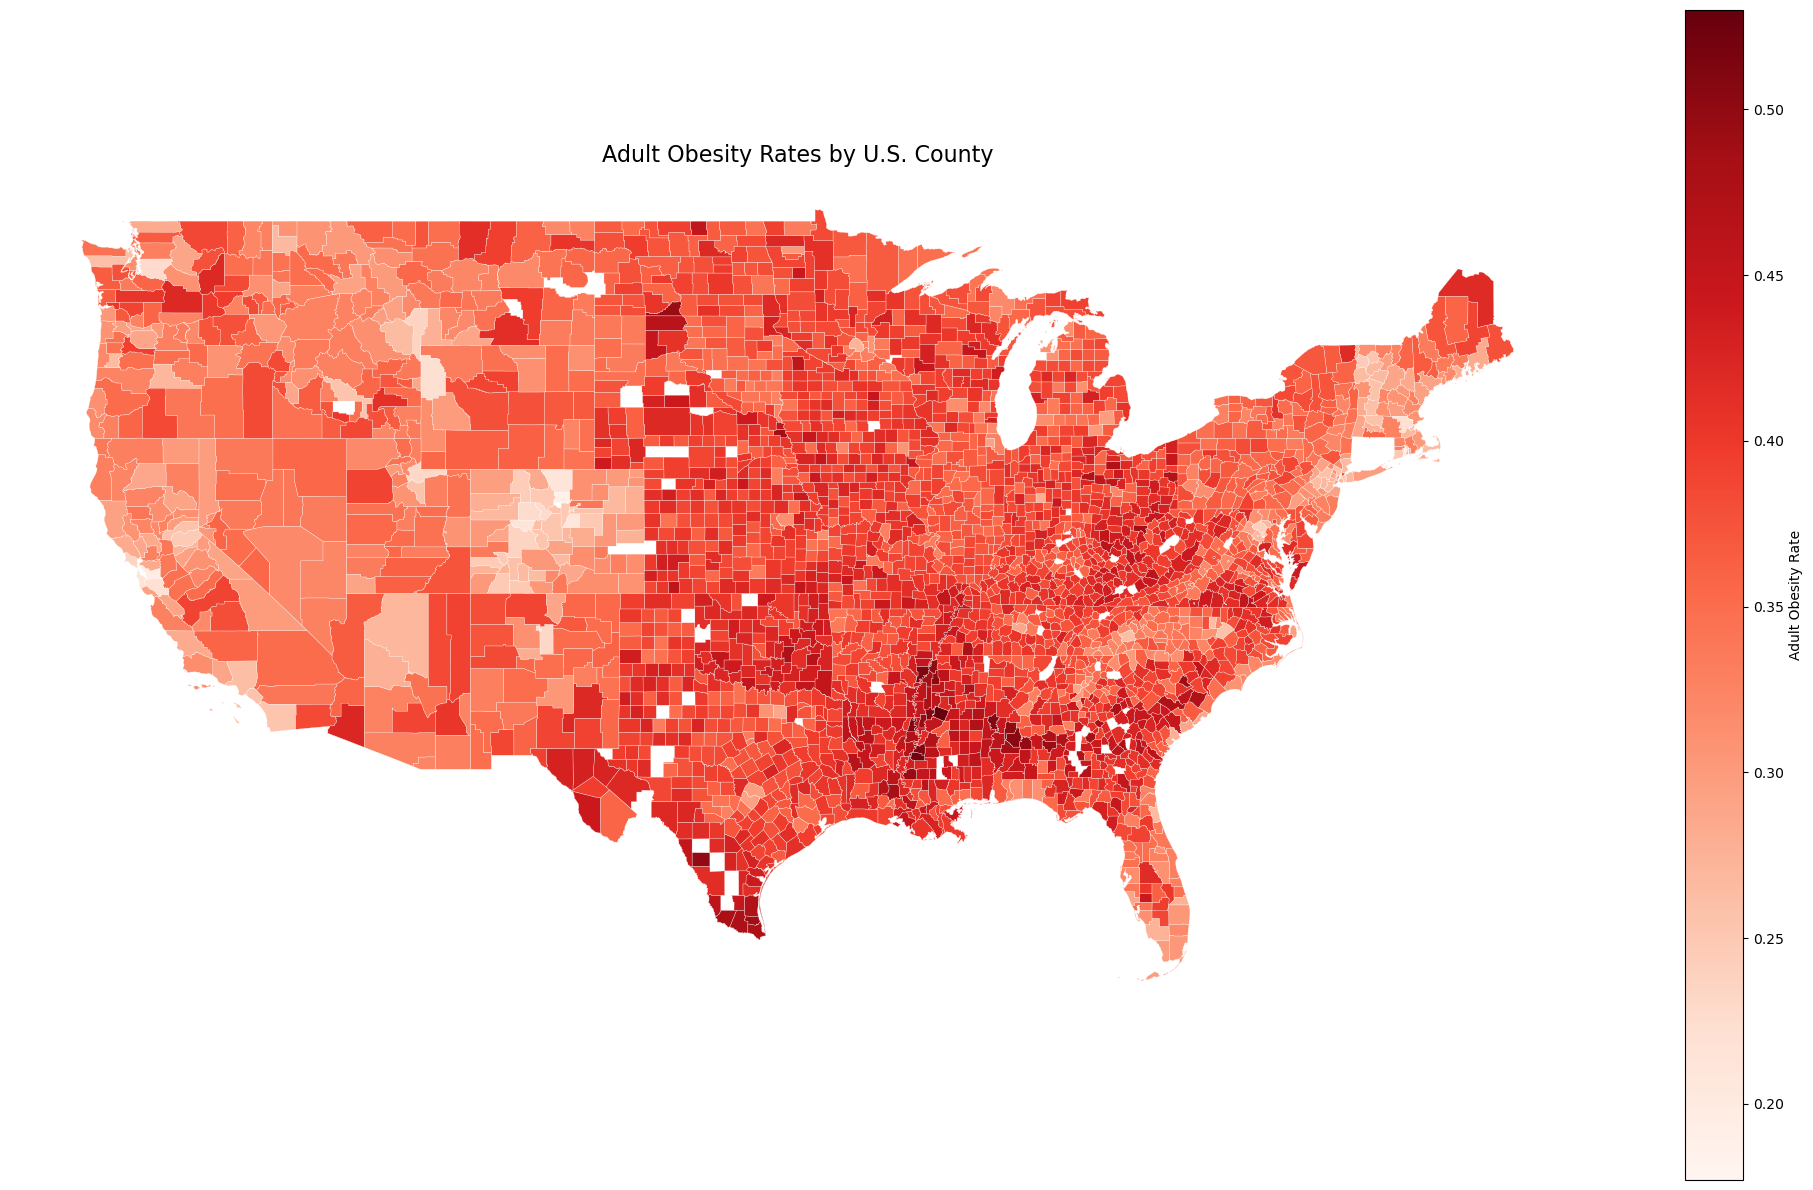

In [113]:
merged = counties.merge(df_clean, left_on='GEOID', right_on='FIPS')
contiguous = merged[~merged['STATEFP'].isin(['02', '15', '72'])]

fig, gax = plt.subplots(figsize=(20, 12))
contiguous.plot(
    ax=gax,
    column='obesity',
    cmap='Reds',
    legend=True,
    legend_kwds={'label': 'Adult Obesity Rate'},
    edgecolor='white',
    linewidth=0.2)
gax.set_title('Adult Obesity Rates by U.S. County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

<div style="color: steelblue; font-size: 14px;">
<b>This choropleth map displays adult obesity rates across all contiguous U.S. counties. Darker red indicates higher obesity rates and lighter shades indicate lower rates. The South and Midwest show significantly higher obesity rates, with many counties exceeding 45%, while the West Coast and Northeast tend to have lower rates, mostly below 30%. The white counties represent missing data where obesity rates were not available. This geographic clustering suggests that regional factors such as income levels, food access, and cultural differences play an important role in explaining obesity disparities across the country.</b>
</div>

## <span style="color:#ff69b4;">PREDICTIVE MODELING — TRAIN/TEST SPLIT</span>

In [118]:
features = ['exercise_access', 'food_env', 'uninsured', 'poverty', 'rural']
X = df_clean[features]
y = df_clean['obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print("Training counties:", X_train.shape[0])
print("Testing counties:", X_test.shape[0])

Training counties: 2483
Testing counties: 621


<div style="color: steelblue; font-size: 14px;">
<b>Here we split the data 80-20 (80% training and 20% testing). We are measuring how well it predicts obesity rates in counties it has never seen. We are also fitting a linear regression model on the training data.</b>
</div>

In [120]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [122]:
y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Out-of-sample R²:   {r2:.3f}")
print(f"Out-of-sample RMSE: {rmse:.4f}")

Out-of-sample R²:   0.357
Out-of-sample RMSE: 0.0379


<div style="color: steelblue; font-size: 14px;">
<b> R^2 = 0.357 which indicates that the model explains 36% of obesity variation in unseen counties. RMSE = 0.038 which indicates that there is an average prediction error of about 3.8 percentage points</b>
</div>

## <span style="color:#ff69b4;">Plot Actual vs Predicted</span>

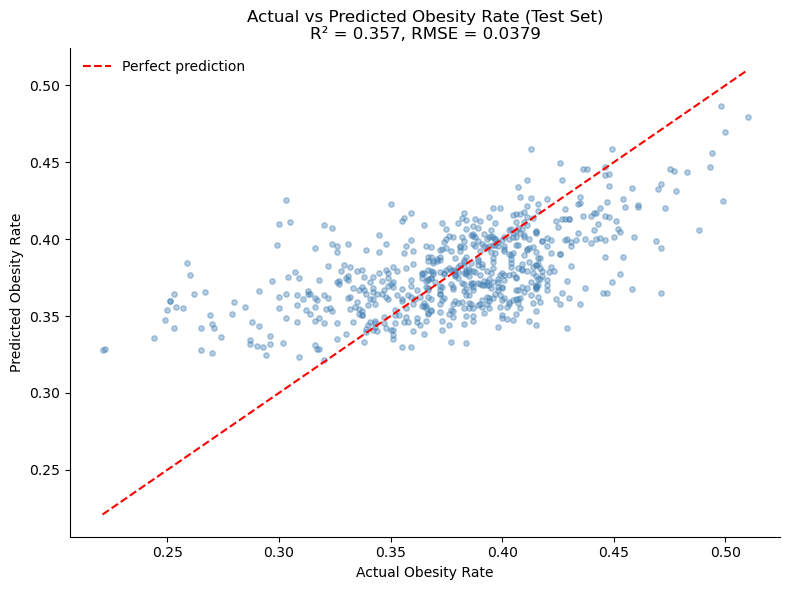

In [128]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual Obesity Rate')
ax.set_ylabel('Predicted Obesity Rate')
ax.set_title(f'Actual vs Predicted Obesity Rate (Test Set)\nR² = {r2:.3f}, RMSE = {rmse:.4f}')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

<div style="color: steelblue; font-size: 14px;">
<b> The points close to the red line mean that the predictions were good while points far from the line are counties that the model struggled to predict. We noticed that the model tends to overpredict low obesity counties but underpredicts high obesity counties (model struggles at the extremes but does well in the average) </b>
</div>

<div style="color: steelblue; font-size: 14px;">
<b> Below, we compared the out of sample R^2 across the models to see how much income improves prediction </b>
</div>

In [132]:
X1_train = X_train[['exercise_access']]
X1_test  = X_test[['exercise_access']]
m1 = LinearRegression().fit(X1_train, y_train)
r2_m1 = r2_score(y_test, m1.predict(X1_test))

df_clean['log_income'] = np.log(df_clean['income'])
X2 = df_clean[['exercise_access', 'log_income']]
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.20, random_state=42)
m2 = LinearRegression().fit(X2_train, y_train)
r2_m2 = r2_score(y_test, m2.predict(X2_test))

X3 = df_clean[['exercise_access', 'log_income', 'food_env', 'uninsured', 'poverty', 'rural']]
X3_train, X3_test, _, _ = train_test_split(X3, y, test_size=0.20, random_state=42)
m3 = LinearRegression().fit(X3_train, y_train)
r2_m3 = r2_score(y_test, m3.predict(X3_test))

print(f"Model 1 (exercise only):    R² = {r2_m1:.3f}")
print(f"Model 2 (+ income):         R² = {r2_m2:.3f}")
print(f"Model 3 (all controls):     R² = {r2_m3:.3f}")

Model 1 (exercise only):    R² = 0.125
Model 2 (+ income):         R² = 0.421
Model 3 (all controls):     R² = 0.430


<div style="color: steelblue; font-size: 14px;">
<b>Based on our results we can see that income definitely does improve prediction (R^2 increased from 12.5% in model 1 to 42.1% in model 2 and 43.0% in model 3. This is consistent with what we found with OLS </b>
</div>

<div style="color: steelblue; font-size: 14px;">
<b>Here we made a confusion matrix to show where the model makes correct and incorrect predictions. </b>
</div>

In [136]:
df_clean['high_obesity'] = (df_clean['obesity'] > df_clean['obesity'].median()).astype(int)

X = df_clean[['exercise_access', 'log_income', 'food_env', 'uninsured', 'poverty', 'rural']]
y = df_clean['high_obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

clf = LogisticRegression(random_state=0).fit(X_train, y_train)
print("Accuracy:", clf.score(X_test, y_test))

y_pred = clf.predict(X_test)
mat = confusion_matrix(y_test, y_pred)
mat_df=pd.DataFrame(mat, index=["Actual Low", "Actual High"], columns=["Predicted Low", "Predicted High"])
mat_df

Accuracy: 0.6827697262479872


,Predicted Low,Predicted High
Actual Low,211,93
Actual High,104,213


<div style="color: steelblue; font-size: 14px;">
<b>Our logistic regression model achieved about 68% accuracy. Of the 621 test counties, 211 low obesity counties and 213 high obesity counties were correctly classified. The most notable part of the matrix are the 104 false negatives (predicted low obesity when actually high) because that suggests that there are factors driving high obesity in some counties that our predictors did not capture. While 68% is better than random, there is room for improvement and it confirms our earlier finding that socioeconomic variables alone do not tell the complete story of county level obesity disparities.</b>
</div>